# Baseline diversification for Integrated Gradients

The [tutorial notebook](integrated_gradients_vit.ipynb) in this folder runs
Integrated Gradients with a single hardcoded baseline: an all-black image. Its
two diagnostic plots — `P(target class)` vs. alpha, and mean |pixel gradient|
vs. alpha — show behaviour that is easy to wave at and hard to interpret: the
probability curve does not climb cleanly, and the gradients do not stay useful
across the whole path.

The usual explanation is that the black baseline is at fault. A straight line
from black to a real photograph passes through uniformly dark, washed-out images
that resemble nothing in the training distribution, so the model's response along
that path is partly a response to the artificiality of the path itself.

This notebook makes the baseline a **parameter** and compares four choices, then
implements **Expected Gradients**, which averages over many baselines rather than
trusting any one of them.

| baseline | path start | keeps the path in-distribution? |
| --- | --- | --- |
| `black` | all zeros | no — the original artefact |
| `random_noise` | uniform noise | no, but breaks black's structural bias |
| `real_image` | another real photo | partly — endpoints real, midpoints are blends |
| `blurred` | Gaussian-blurred **input** | yes — every step is a plausible photo |

## What is in `src/`

Developer notes: [`src/img_interp/README.md`](../../src/img_interp/README.md).

| Symbol | Role |
| --- | --- |
| `loading.load_model` / `.load_example_images` / `.load_baseline_pool` | Inception V1 from TF-Hub, the tutorial's two photos, and a pool of real images to draw baselines from |
| `baselines.make_baseline` | builds any of the four baseline types |
| `baselines.gaussian_blur_image` | separable Gaussian blur, used by the `blurred` baseline |
| `ig.integrated_gradients` | IG with the baseline as an argument; optionally returns the path diagnostics |
| `ig.expected_gradients` | IG averaged over N real-image baselines |
| `ig.completeness_error` | how far the attribution is from IG's completeness axiom |
| `diagnostics.summarize_path` | turns the two curves into comparable numbers |


In [1]:
import sys, os
sys.path.insert(0, "../../src")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from img_interp import loading, baselines, ig, diagnostics

model = loading.load_model()
labels = loading.load_imagenet_labels()
images = loading.load_example_images()

IMAGE_NAME = "Fireboat"
image = images[IMAGE_NAME]
target = loading.EXAMPLE_TARGETS[IMAGE_NAME]
print(f"explaining '{IMAGE_NAME}' as class {target} ({labels[target]})")

I0000 00:00:1789568283.383779    1954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789568283.384318    1954 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1789568284.807974    1954 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789568284.808280    1954 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


 8192/10484 [======================>.......] - ETA: 0s

10484/10484 [==============================] - 0s 0us/step


explaining 'Fireboat' as class 555 (fireboat)


## 1. A pool of real images

Expected Gradients and the `real_image` baseline both need real photographs to
draw from. We use TensorFlow's `flower_photos` set — one reliable download.

These are deliberately **not** images of the class being explained. A baseline is
supposed to be a neutral reference point; drawing it from the target class would
leak the answer into the reference.

baseline pool: (40, 224, 224, 3)


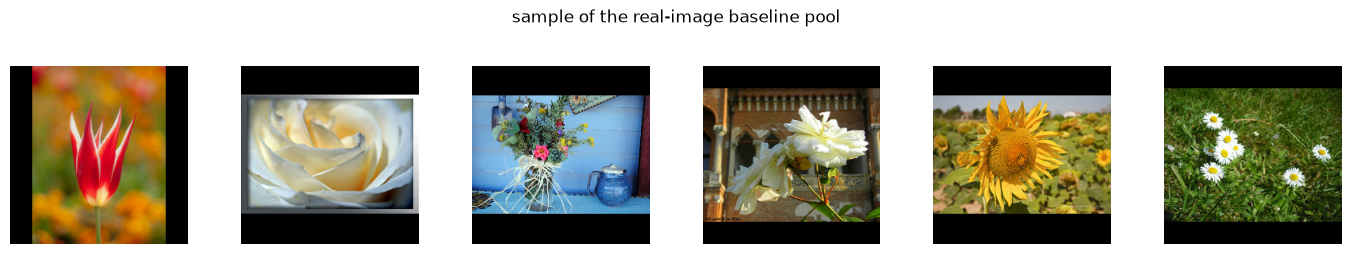

In [2]:
pool = loading.load_baseline_pool(n_images=40, seed=0)
print("baseline pool:", pool.shape)

fig, axes = plt.subplots(1, 6, figsize=(14, 2.4))
for ax, im in zip(axes, pool[:6]):
    ax.imshow(im); ax.axis("off")
fig.suptitle("sample of the real-image baseline pool", y=1.04)
plt.tight_layout(); plt.show()

## 2. The four baselines

`make_baseline` builds each one. Note that `blurred` is the only baseline derived
from the input itself — it is the same photograph with its detail destroyed,
which is why interpolating toward the original never leaves the space of
plausible images.

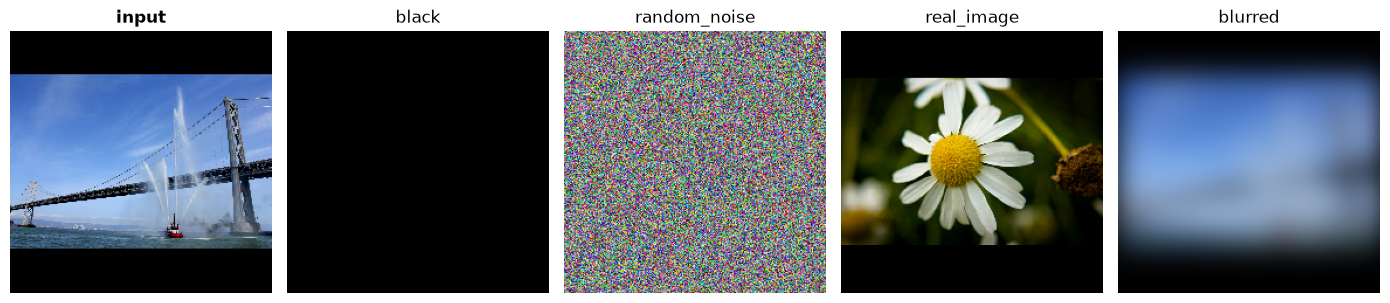

In [3]:
KINDS = ["black", "random_noise", "real_image", "blurred"]
bl = {k: baselines.make_baseline(k, image, pool=pool, seed=0) for k in KINDS}

fig, axes = plt.subplots(1, 5, figsize=(14, 3))
axes[0].imshow(image); axes[0].set_title("input", fontweight="bold"); axes[0].axis("off")
for ax, k in zip(axes[1:], KINDS):
    ax.imshow(tf.clip_by_value(bl[k], 0, 1)); ax.set_title(k); ax.axis("off")
plt.tight_layout(); plt.show()

### What the interpolation path actually looks like

This is the crux of the whole notebook. Compare the middle of each row: the
`black` and `real_image` rows pass through images no camera would produce, while
the `blurred` row is a plausible photograph at every step — just progressively
sharper.

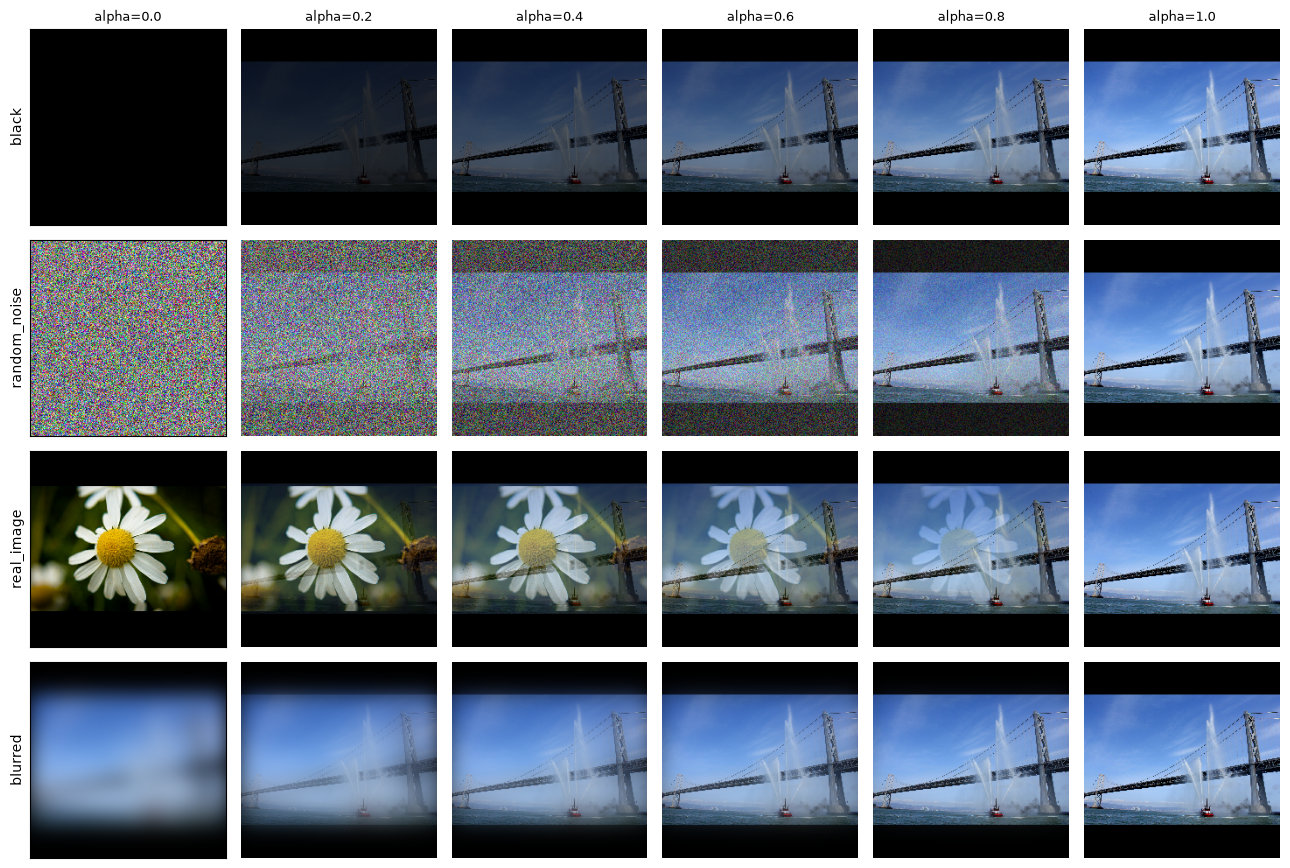

In [4]:
alphas_show = tf.linspace(0.0, 1.0, 6)
fig, axes = plt.subplots(len(KINDS), 6, figsize=(13, 2.2 * len(KINDS)))
for row, k in enumerate(KINDS):
    path = ig.interpolate_images(bl[k], image, alphas_show)
    for col, (a, im) in enumerate(zip(alphas_show, path)):
        axes[row, col].imshow(tf.clip_by_value(im, 0, 1))
        axes[row, col].axis("off")
        if row == 0:
            axes[row, col].set_title(f"alpha={a:.1f}", fontsize=9)
    axes[row, 0].set_ylabel(k)
    axes[row, 0].axis("on"); axes[row, 0].set_xticks([]); axes[row, 0].set_yticks([])
plt.tight_layout(); plt.show()

## 3. The diagnostic plots, one pair per baseline

These are the two plots the tutorial produces, now computed for each baseline so
they can be read side by side. The probability curves are on shared axes to make
the comparison direct.

What to look for:

- **Saturation** — a gradient curve that sits near zero for much of the path.
  Those alphas contribute nothing to the integral, so the attribution is decided
  by a narrow slice of the path.
- **Backtracking** — a probability curve that rises and then falls. It means the
  path passes through states the model likes *more* than the actual input.

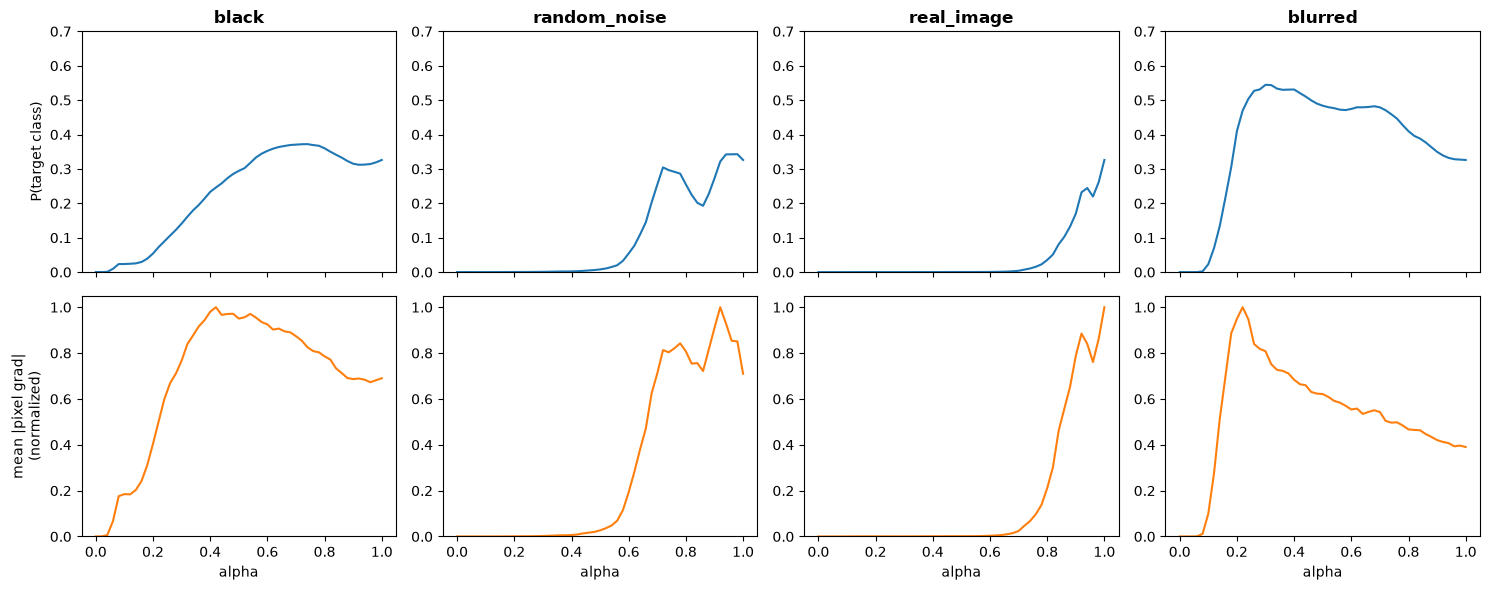

In [5]:
M_STEPS = 50
diag = {}
for k in KINDS:
    _, diag[k] = ig.integrated_gradients(
        model, image, target, baseline=bl[k], m_steps=M_STEPS, return_diagnostics=True
    )

fig, axes = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
for col, k in enumerate(KINDS):
    d = diag[k]
    axes[0, col].plot(d.alphas, d.probs, color="tab:blue")
    axes[0, col].set_title(k, fontweight="bold"); axes[0, col].set_ylim(0, 0.7)
    axes[1, col].plot(d.alphas, d.mean_abs_grads / d.mean_abs_grads.max(), color="tab:orange")
    axes[1, col].set_ylim(0, 1.05); axes[1, col].set_xlabel("alpha")
axes[0, 0].set_ylabel("P(target class)")
axes[1, 0].set_ylabel("mean |pixel grad|\n(normalized)")
plt.tight_layout(); plt.show()

## 4. Expected Gradients

Any single baseline injects its own structure into the explanation. The black
baseline has a particularly clear version of this problem: attribution is scaled
by `(image - baseline)`, so where the image is genuinely black that factor is
zero and those pixels **cannot receive attribution at all**, regardless of how
much the model relies on them.

Expected Gradients removes the dependence on one arbitrary choice by sampling N
real-image baselines, running the full IG path for each, and averaging the
attributions. Below, the diagnostic curves are aggregated across the N runs as a
mean with a ±1 std band, so the spread across baselines is visible rather than
hidden.

In [6]:
N_BASELINES = 25
eg_attr, eg_diags = ig.expected_gradients(
    model, image, target, pool=pool,
    n_baselines=N_BASELINES, m_steps=M_STEPS, seed=0, progress=True,
)
band = ig.stack_diagnostics(eg_diags)
print(f"averaged over {N_BASELINES} real-image baselines")

averaged over 25 real-image baselines


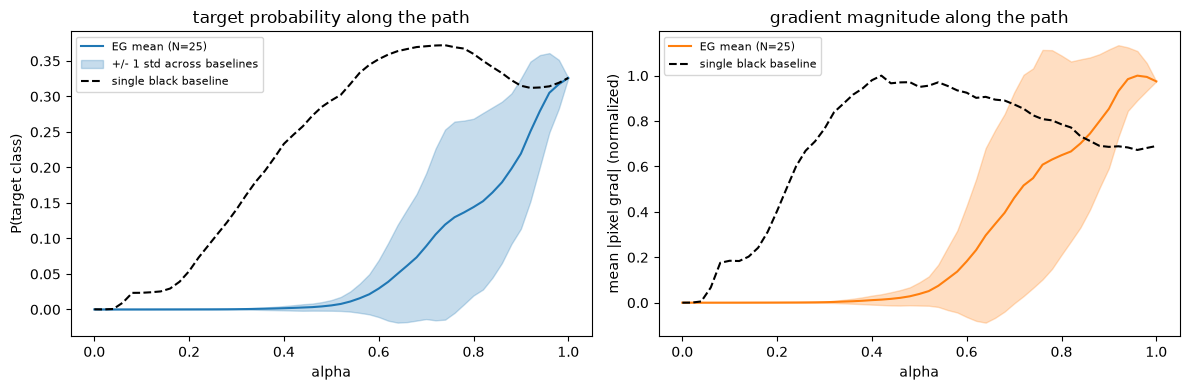

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(band["alphas"], band["probs_mean"], color="tab:blue", label=f"EG mean (N={N_BASELINES})")
axes[0].fill_between(band["alphas"], band["probs_mean"] - band["probs_std"],
                     band["probs_mean"] + band["probs_std"], alpha=0.25, color="tab:blue",
                     label="+/- 1 std across baselines")
axes[0].plot(diag["black"].alphas, diag["black"].probs, "--", color="k", label="single black baseline")
axes[0].set_xlabel("alpha"); axes[0].set_ylabel("P(target class)"); axes[0].legend(fontsize=8)
axes[0].set_title("target probability along the path")

g_mean = band["grads_mean"] / band["grads_mean"].max()
g_std = band["grads_std"] / band["grads_mean"].max()
axes[1].plot(band["alphas"], g_mean, color="tab:orange", label=f"EG mean (N={N_BASELINES})")
axes[1].fill_between(band["alphas"], g_mean - g_std, g_mean + g_std, alpha=0.25, color="tab:orange")
bg = diag["black"].mean_abs_grads
axes[1].plot(diag["black"].alphas, bg / bg.max(), "--", color="k", label="single black baseline")
axes[1].set_xlabel("alpha"); axes[1].set_ylabel("mean |pixel grad| (normalized)")
axes[1].legend(fontsize=8); axes[1].set_title("gradient magnitude along the path")
plt.tight_layout(); plt.show()

## 5. The attribution maps

The diagnostics describe the *path*; these are the attributions that come out the
other end. There is no ground truth on a real photograph, so this comparison is
qualitative by necessity — which is exactly why the quantitative method
comparisons in this repo live on the
[time-series side](../time_series/occlusion_vs_integrated_gradients.ipynb), where
the important region is known by construction.

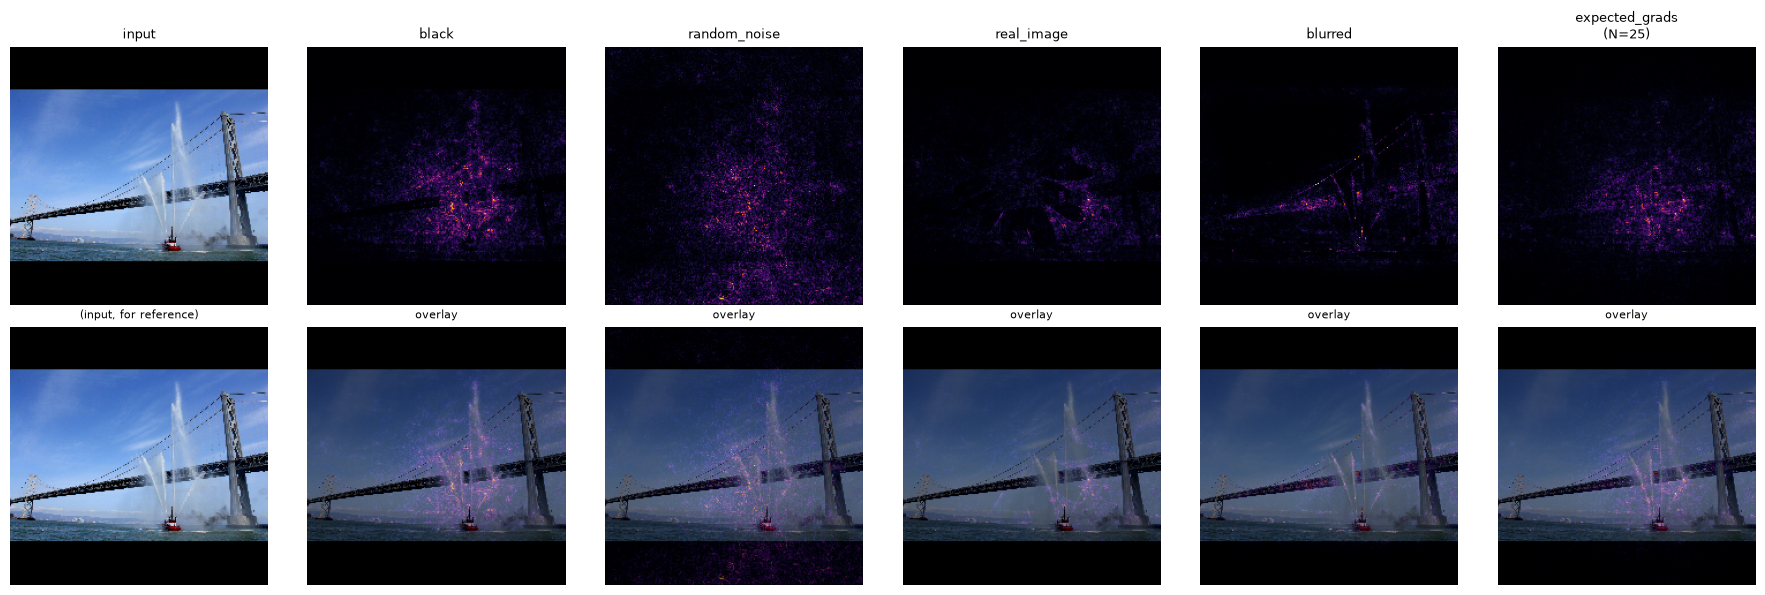

In [8]:
def attribution_mask(a):
    return tf.reduce_sum(tf.math.abs(a), axis=-1)

eg_name = f"expected_grads\n(N={N_BASELINES})"
maps = {k: attribution_mask(ig.integrated_gradients(
            model, image, target, baseline=bl[k], m_steps=M_STEPS)) for k in KINDS}
maps[eg_name] = attribution_mask(eg_attr)

panels = [("input", image, None)] + [(n, m, "inferno") for n, m in maps.items()]

fig, axes = plt.subplots(2, len(panels), figsize=(3 * len(panels), 6))
for col, (name, data, cmap) in enumerate(panels):
    axes[0, col].imshow(data, cmap=cmap)
    axes[0, col].set_title(name, fontsize=9)
    axes[0, col].axis("off")

    # bottom row: the same attribution overlaid on the photo
    axes[1, col].imshow(image)
    if cmap is not None:
        axes[1, col].imshow(data, cmap=cmap, alpha=0.5)
        axes[1, col].set_title("overlay", fontsize=8)
    axes[1, col].axis("off")
axes[1, 0].set_title("(input, for reference)", fontsize=8)
plt.tight_layout(); plt.show()

## 6. Summary — did the artefacts improve?

Three descriptive numbers per baseline. These **describe the diagnostic plots**;
they are not a quality metric for the attributions, and a better number here does
not by itself mean a better explanation.

- **backtrack** — total downward movement of `P(target)` as a fraction of its net
  rise. 0% is perfectly monotone; large values mean the path overshoots.
- **saturated** — fraction of the path whose gradient magnitude is under 10% of
  the path's peak. High values mean most of the integration range contributes
  nothing.
- **completeness err** — how far the attribution is from IG's completeness axiom
  (`sum(attributions)` should equal `F(image) - F(baseline)`). A large gap means
  the Riemann sum has not converged at this `m_steps`.

In [9]:
rows = []
for k in KINDS:
    r = diagnostics.summarize_path(diag[k], k)
    r["completeness_err"] = ig.completeness_error(
        model, image, bl[k], target,
        ig.integrated_gradients(model, image, target, baseline=bl[k], m_steps=M_STEPS))
    rows.append(r)

eg_row = {
    "baseline": f"expected_grads(N={N_BASELINES})",
    "decreasing_steps": diagnostics.decreasing_step_fraction(band["probs_mean"]),
    "backtrack": diagnostics.backtrack_fraction(band["probs_mean"]),
    "saturation_frac": diagnostics.saturation_fraction(band["grads_mean"]),
    "prob_start": float(band["probs_mean"][0]),
    "prob_end": float(band["probs_mean"][-1]),
    "completeness_err": float("nan"),
}
rows.append(eg_row)

print(diagnostics.format_table(rows))
print()
for r in rows:
    ce = r["completeness_err"]
    print(f"  {r['baseline']:<26} completeness err = " +
          ("n/a (averaged)" if not np.isfinite(ce) else f"{ce:.4f}"))

baseline              backtrack  saturated  dec.steps  P(start)   P(end)
------------------------------------------------------------------------
black                     18.5%      7.8%     20.0%     0.000    0.326
random_noise              39.4%     56.9%     22.0%     0.000    0.326
real_image                 7.6%     76.5%     16.0%     0.000    0.326
blurred                   70.7%     11.8%     62.0%     0.000    0.326
expected_grads(N=25)      -0.0%     54.9%      0.0%     0.000    0.326

  black                      completeness err = 0.0108
  random_noise               completeness err = 0.0472
  real_image                 completeness err = 0.0426
  blurred                    completeness err = 0.0068
  expected_grads(N=25)       completeness err = n/a (averaged)


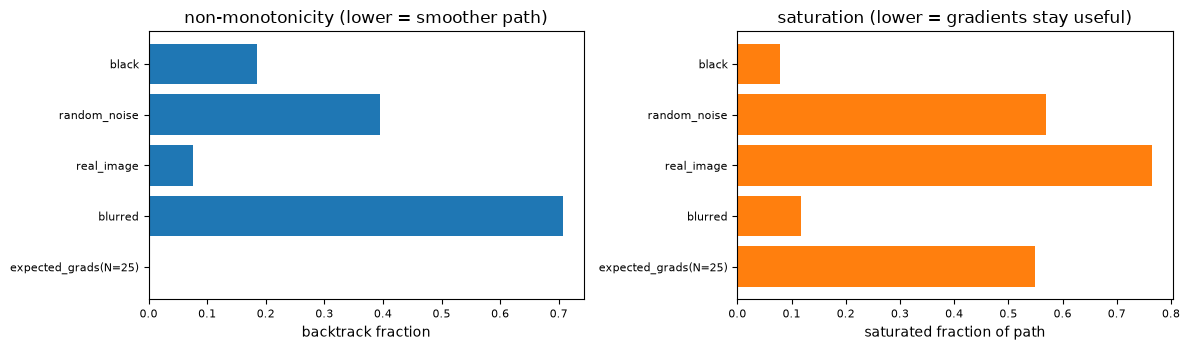

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
names = [r["baseline"] for r in rows]
bt = [r["backtrack"] if np.isfinite(r["backtrack"]) else 0 for r in rows]
sat = [r["saturation_frac"] for r in rows]

ax[0].barh(names, bt, color="tab:blue"); ax[0].set_xlabel("backtrack fraction")
ax[0].set_title("non-monotonicity (lower = smoother path)")
ax[1].barh(names, sat, color="tab:orange"); ax[1].set_xlabel("saturated fraction of path")
ax[1].set_title("saturation (lower = gradients stay useful)")
for a in ax:
    a.invert_yaxis(); a.tick_params(labelsize=8)
plt.tight_layout(); plt.show()

## Takeaways

*(filled in from the executed numbers above — see the table.)*